### 1. Importacion de librerias y login

In [1]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import os
import kagglehub

In [3]:
kagglehub.login()

In [4]:
#KAGGLE_API_TOKEN=KGAT_a55f30e97f73bc5a376cb027bea79c4d

### 2. Descarga del dataset

In [5]:
# Download latest version
path = kagglehub.competition_download('mtc-smart-challenge-ia-para-la-movilidad-del-peru')

print("Path to competition files:", path)

Path to competition files: C:\Users\HAROLD\.cache\kagglehub\competitions\mtc-smart-challenge-ia-para-la-movilidad-del-peru


In [6]:
# Celda 7 — Exploración dinámica de la estructura del dataset
from pathlib import Path

# Resolución dinámica de dataset_root
dataset_root = path if 'path' in dir() else None
if dataset_root is None:
    for root, dirs, files in os.walk(os.path.expanduser('~/.cache/kagglehub/competitions')):
        if files:
            dataset_root = root
            break

print(f"Raíz del dataset: {dataset_root}\n")

# ── Detectar si kagglehub descargó una página HTML de Google Drive ──────────
try:
    import gdown
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gdown', '-q'])
    import gdown

dir_items = [f for f in os.listdir(dataset_root)
             if os.path.isfile(os.path.join(dataset_root, f))]

for item in dir_items:
    ipath = os.path.join(dataset_root, item)
    with open(ipath, 'rb') as fh:
        magic = fh.read(20)
    if b'<!DOCTYPE' in magic or b'<html' in magic.lower():
        print(f"[AVISO] '{item}' es una pagina HTML de Google Drive.")
        print("        kagglehub no descargo los datos reales.\n")
        DRIVE_FILES = [
            ('train.csv',             '15uryIw5IEn8y67hSJUqBqXV8fUPVS4ME'),
            ('sample_submission.csv', '1-X_0QFKTGePx59_dNyJQ01Q_Y6s1Ri1V'),
        ]
        for fname, fid in DRIVE_FILES:
            dest = os.path.join(dataset_root, fname)
            if not os.path.exists(dest):
                print(f"  Descargando {fname} desde Google Drive...")
                gdown.download(id=fid, output=dest, quiet=False)
            else:
                print(f"  {fname} ya existe ({os.path.getsize(dest)/1e6:.1f} MB) — omitiendo.")
        print()
        break

# ── Listar estructura ────────────────────────────────────────────────────────
total_size = 0
file_count = 0
dir_summary: dict = {}

for root, dirs, files in os.walk(dataset_root):
    rel_root = os.path.relpath(root, dataset_root)
    if files:
        dir_files = []
        for fname in sorted(files):
            fpath = os.path.join(root, fname)
            fsize = os.path.getsize(fpath)
            total_size += fsize
            file_count += 1
            dir_files.append((fname, fsize, Path(fname).suffix.lower()))
        dir_summary[rel_root] = dir_files

for dir_path, files in sorted(dir_summary.items()):
    print(f"[DIR] {dir_path}/")
    for fname, fsize, ext in files[:25]:
        size_str = f"{fsize/1024:.1f} KB" if fsize < 1e6 else f"{fsize/1e6:.2f} MB"
        print(f"  {fname:50s}  {size_str:>10s}")
    if len(files) > 25:
        print(f"  ... y {len(files)-25} archivos mas")

print(f"\n{'='*60}")
print(f"Total archivos : {file_count}")
print(f"Tamano total   : {total_size/1e6:.2f} MB")

VIDEO_EXT = {'.mp4', '.avi', '.mov', '.mkv'}
all_extensions: set = {ext for files in dir_summary.values() for _, _, ext in files}
HAS_VIDEOS = bool(all_extensions & VIDEO_EXT)

zip_present = any(ext == '.zip' for files in dir_summary.values() for _, _, ext in files)
if not zip_present:
    print("\n[INFO] train.zip y test.zip (imagenes/videos) aun no descargados.")
    print("       IDs de Google Drive para descargar manualmente o con gdown:")
    print("   train.zip : 17OtCP69233c_oReSrWBUurIPtJRUE06U")
    print("   test.zip  : 1vM55t1zWZizJNPXULZXsnApg8wWj38MK")
    print("   Comando   : gdown --id <ID> -O <destino>")


Raíz del dataset: C:\Users\HAROLD\.cache\kagglehub\competitions\mtc-smart-challenge-ia-para-la-movilidad-del-peru

[AVISO] '1gnCApZW1oUsh1Bb1LtSQlEeoBGmC9AjA' es una pagina HTML de Google Drive.
        kagglehub no descargo los datos reales.

  train.csv ya existe (20.3 MB) — omitiendo.
  sample_submission.csv ya existe (0.6 MB) — omitiendo.

[DIR] ./
  1gnCApZW1oUsh1Bb1LtSQlEeoBGmC9AjA                     295.9 KB
  sample_submission.csv                                 552.6 KB
  train.csv                                             20.35 MB

Total archivos : 3
Tamano total   : 21.22 MB

[INFO] train.zip y test.zip (imagenes/videos) aun no descargados.
       IDs de Google Drive para descargar manualmente o con gdown:
   train.zip : 17OtCP69233c_oReSrWBUurIPtJRUE06U
   test.zip  : 1vM55t1zWZizJNPXULZXsnApg8wWj38MK
   Comando   : gdown --id <ID> -O <destino>


In [7]:
# Celda 8 — Carga y parsing de train.csv

# Buscar train.csv con os.walk (no se asume path fijo)
train_csv_path = None
for root, dirs, files in os.walk(dataset_root):
    for fname in files:
        if fname.lower() == 'train.csv':
            train_csv_path = os.path.join(root, fname)
            break
    if train_csv_path:
        break

if train_csv_path is None:
    raise FileNotFoundError(
        "No se encontro train.csv. Verifica que la celda 7 haya descargado los archivos."
    )

print(f"train.csv encontrado en:\n  {train_csv_path}\n")

# ── CSV crudo: 2 columnas (Id, Target) ─────────────────────────────────────
df_raw = pd.read_csv(train_csv_path)
print(f"CSV crudo   : {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print(f"Columnas    : {list(df_raw.columns)}")
print(f"\nFormato Target (muestra):\n  {str(df_raw['Target'].iloc[0])[:140]}")

none_mask = df_raw['Target'].astype(str).str.strip().str.lower().eq('none')
print(f"\nFrames sin deteccion ('none') : {none_mask.sum():,}")
print(f"Frames con detecciones        : {(~none_mask).sum():,}")

# ── Parsear Target -> df_ann (1 fila = 1 deteccion OBB) ────────────────────
# Formato por anotacion: "category_id cx cy width height angle_deg"
# Multiples anotaciones separadas por ";"
print("\nParseando anotaciones OBB...")

records = []
for _, row in df_raw.iterrows():
    tgt = str(row['Target']).strip()
    if tgt.lower() == 'none' or not tgt:
        continue
    frame_id = row['Id']
    parts_id = frame_id.rsplit('_', 1)
    video_id = parts_id[0] if len(parts_id) == 2 else frame_id
    for ann in tgt.split(';'):
        p = ann.strip().split()
        if len(p) >= 6:
            records.append({
                'frame_id'   : frame_id,
                'video_id'   : video_id,
                'category_id': int(p[0]),
                'cx'         : float(p[1]),
                'cy'         : float(p[2]),
                'width'      : float(p[3]),
                'height'     : float(p[4]),
                'angle_deg'  : float(p[5]),
            })

df_ann = pd.DataFrame(records)
print(f"OK — df_ann: {df_ann.shape[0]:,} detecciones x {df_ann.shape[1]} columnas\n")
print("Columnas:")
print(df_ann.dtypes.to_string())
null_counts = df_ann.isnull().sum()
print("\nValores nulos:", "Ninguno." if null_counts.sum() == 0
      else null_counts[null_counts > 0].to_string())
print(f"\nVideos unicos : {df_ann['video_id'].nunique():,}")
print(f"Frames unicos : {df_ann['frame_id'].nunique():,}")
df_ann.head()


train.csv encontrado en:
  C:\Users\HAROLD\.cache\kagglehub\competitions\mtc-smart-challenge-ia-para-la-movilidad-del-peru\train.csv

CSV crudo   : 54,262 filas x 2 columnas
Columnas    : ['Id', 'Target']

Formato Target (muestra):
  1 533.545 1016.865 77.75 35.87 0;1 909.665 843.46 38.17 86.5 0;1 915.965 949.2 32.35 77.3 0;1 918.505 1048.55 35.61 62.9 0;1 932.185 399.935

Frames sin deteccion ('none') : 3,394
Frames con detecciones        : 50,868

Parseando anotaciones OBB...
OK — df_ann: 601,934 detecciones x 8 columnas

Columnas:
frame_id           str
video_id           str
category_id      int64
cx             float64
cy             float64
width          float64
height         float64
angle_deg      float64

Valores nulos: Ninguno.

Videos unicos : 1,047
Frames unicos : 50,868


,frame_id,video_id,category_id,cx,cy,width,height,angle_deg
0,v_009evckk5b_0000,v_009evckk5b,1,533.545,1016.865,77.75,35.87,0.00
1,v_009evckk5b_0000,v_009evckk5b,1,909.665,843.460,38.17,86.50,0.00
2,v_009evckk5b_0000,v_009evckk5b,1,915.965,949.200,32.35,77.30,0.00
3,v_009evckk5b_0000,v_009evckk5b,1,918.505,1048.550,35.61,62.90,0.00
4,v_009evckk5b_0000,v_009evckk5b,1,932.185,399.935,35.25,81.19,346.35


Columna de categoria: 'category_id' | Total detecciones: 601,934



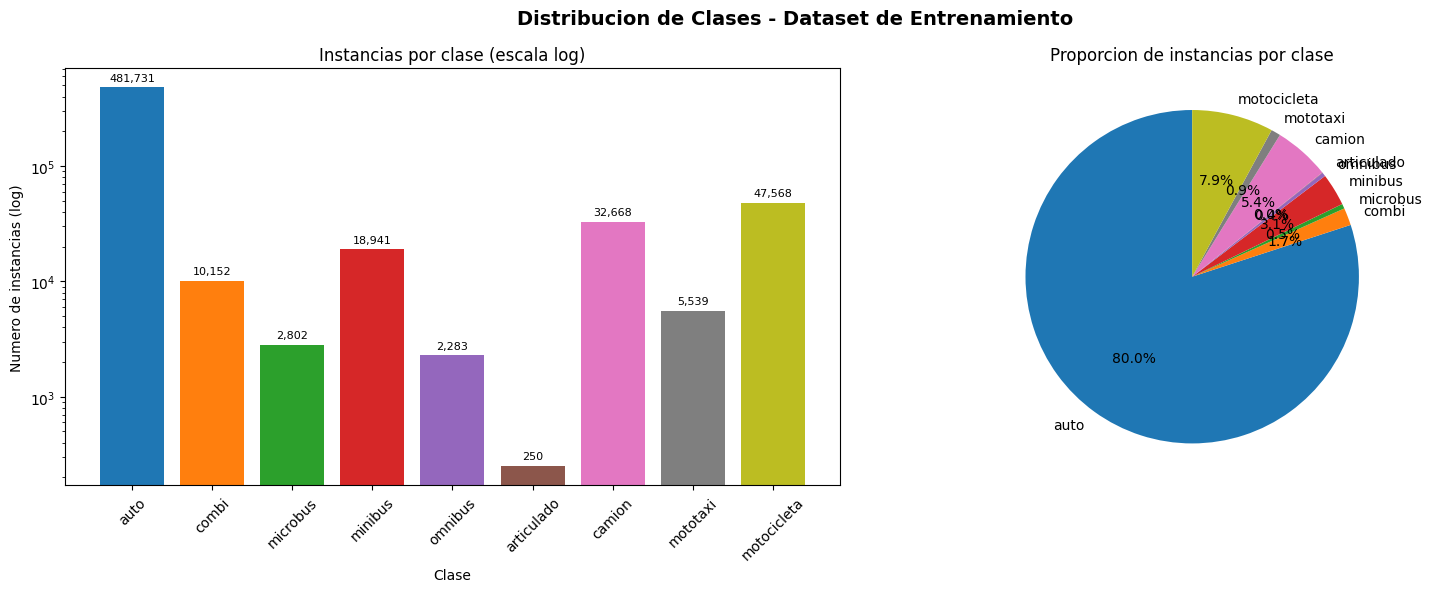


REPORTE DE DESBALANCE DE CLASES
Clase            ID      Count        %
----------------------------------------
auto              1    481,731   80.03%
combi             2     10,152    1.69%
microbus          3      2,802    0.47%
minibus           4     18,941    3.15%
omnibus           5      2,283    0.38%
articulado        6        250    0.04%
camion            7     32,668    5.43%
mototaxi          8      5,539    0.92%
motocicleta       9     47,568    7.90%

Clase mas frecuente  : auto (481,731)
Clase menos frecuente: articulado (250)
Ratio de desbalance (max/min): 1926.9x  [SEVERO]


In [8]:
# Celda 9 — EDA de distribucion de clases

import matplotlib.pyplot as plt

CLASS_NAMES = {
    1: 'auto', 2: 'combi', 3: 'microbus', 4: 'minibus',
    5: 'omnibus', 6: 'articulado', 7: 'camion', 8: 'mototaxi', 9: 'motocicleta'
}


def find_column(df, candidates):
    """Detecta nombre de columna por matching fuzzy (case-insensitive, partial)."""
    cols_lower = {c.lower().replace(' ', '_'): c for c in df.columns}
    for cand in candidates:
        if cand in cols_lower:
            return cols_lower[cand]
    for cand in candidates:
        for col_lower, col_orig in cols_lower.items():
            if cand in col_lower:
                return col_orig
    return None


# Guard: df_ann debe existir con columnas OBB (creado en celda 8)
if 'df_ann' not in dir() or 'category_id' not in df_ann.columns:
    raise RuntimeError(
        "df_ann no tiene las columnas OBB esperadas.\n"
        "Reinicia el kernel y ejecuta las celdas en orden (celda 8 antes que esta)."
    )

cat_col = 'category_id'   # columna explicita tras el parsing
print(f"Columna de categoria: '{cat_col}' | Total detecciones: {len(df_ann):,}\n")

counts = df_ann[cat_col].value_counts().sort_index()
labels = [CLASS_NAMES.get(int(k), str(k)) for k in counts.index]
colors_tab = [plt.cm.tab10(i) for i in range(len(labels))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribucion de Clases - Dataset de Entrenamiento', fontsize=14, fontweight='bold')

ax1 = axes[0]
bars = ax1.bar(labels, counts.values, color=colors_tab)
ax1.set_yscale('log')
ax1.set_title('Instancias por clase (escala log)')
ax1.set_xlabel('Clase')
ax1.set_ylabel('Numero de instancias (log)')
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.1,
             f'{val:,}', ha='center', va='bottom', fontsize=8)

ax2 = axes[1]
ax2.pie(counts.values, labels=labels, autopct='%1.1f%%',
        colors=colors_tab, startangle=90)
ax2.set_title('Proporcion de instancias por clase')

plt.tight_layout()
plt.show()

print(f"\n{'='*52}")
print("REPORTE DE DESBALANCE DE CLASES")
print(f"{'='*52}")
print(f"{'Clase':<15} {'ID':>3} {'Count':>10} {'%':>8}")
print('-' * 40)
total_instances = counts.sum()
for idx, count in counts.items():
    name = CLASS_NAMES.get(int(idx), str(idx))
    print(f"{name:<15} {int(idx):>3} {count:>10,} {100 * count / total_instances:>7.2f}%")

max_count, min_count = counts.max(), counts.min()
ratio = max_count / min_count
max_class = CLASS_NAMES.get(int(counts.idxmax()), str(counts.idxmax()))
min_class = CLASS_NAMES.get(int(counts.idxmin()), str(counts.idxmin()))
print(f"\nClase mas frecuente  : {max_class} ({max_count:,})")
print(f"Clase menos frecuente: {min_class} ({min_count:,})")
severity = "SEVERO" if ratio > 10 else "MODERADO"
print(f"Ratio de desbalance (max/min): {ratio:.1f}x  [{severity}]")


Columnas OBB (del parsing en celda 8):
  cx      : OK  'cx'
  cy      : OK  'cy'
  width   : OK  'width'
  height  : OK  'height'
  angle   : OK  'angle_deg'

[NOTA] Angulo mediano = 0.000 — posiblemente en RADIANES. Verifica antes de entrenar.
     60.4% de los OBB tienen angulo exactamente 0.


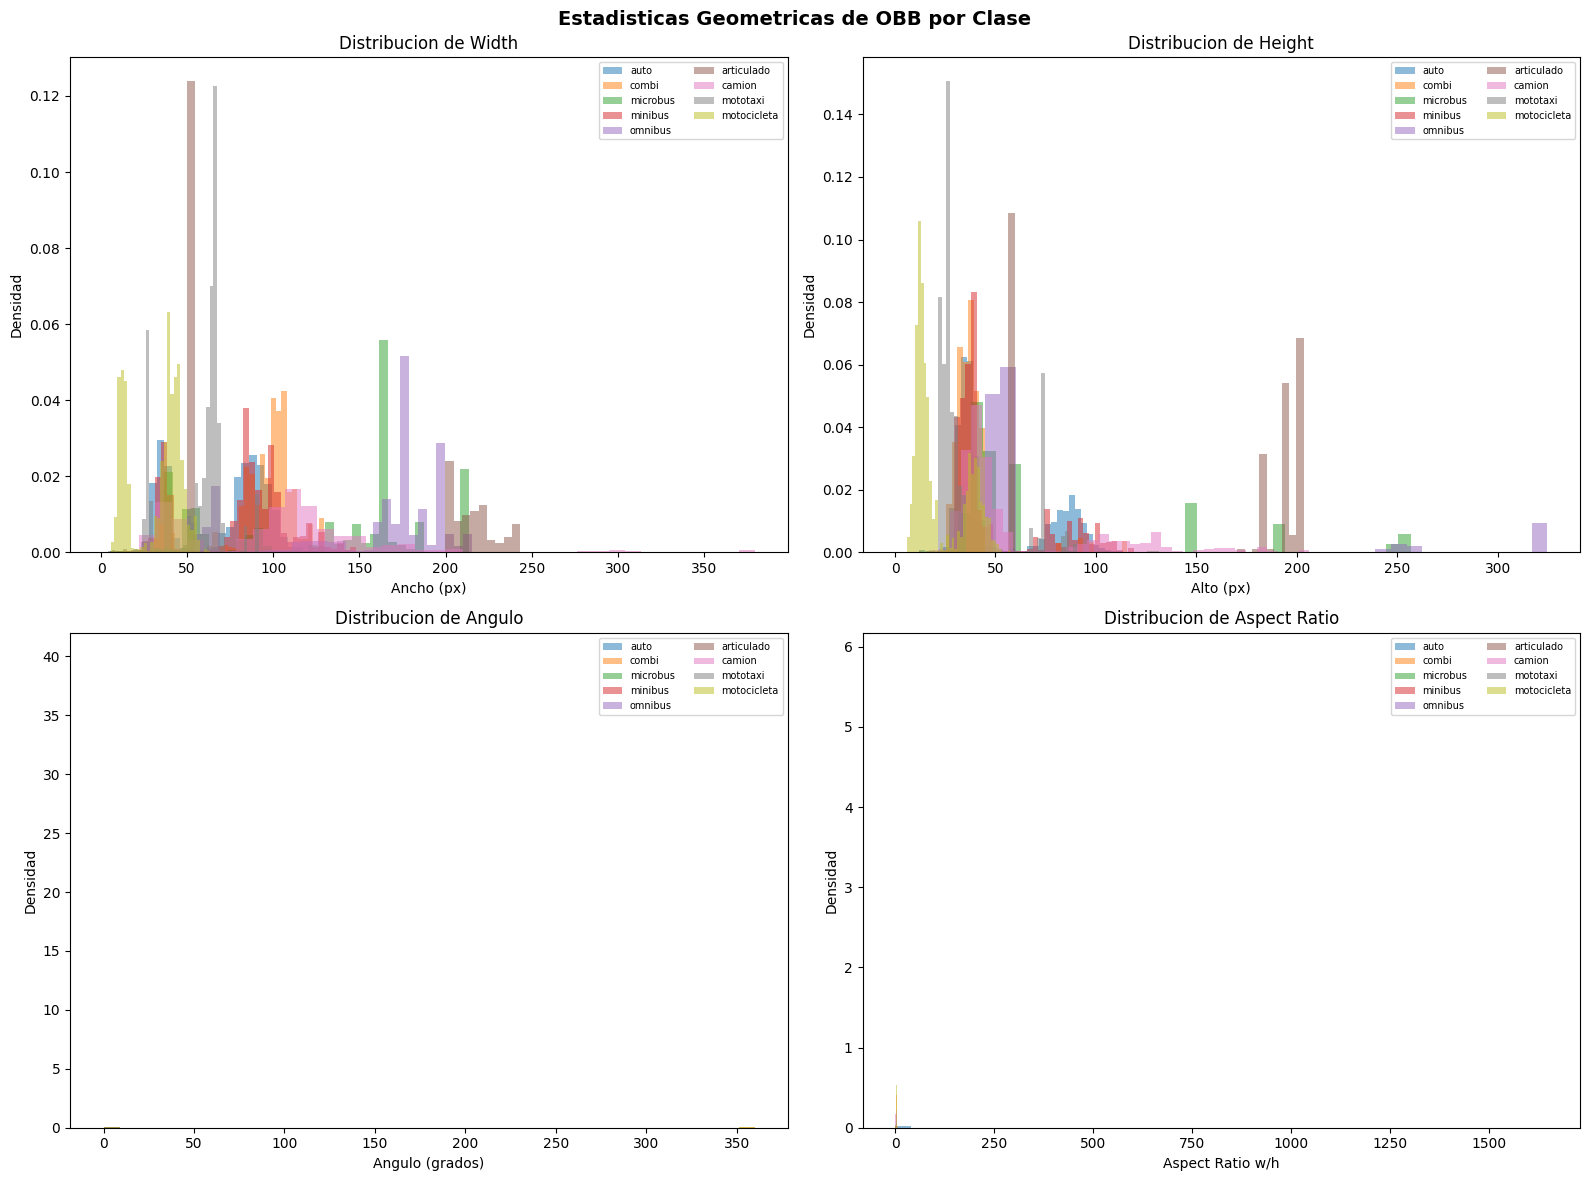


Estadisticas por clase (media +/- std):
              width         height        angle_deg         _aspect_ratio      
               mean    std    mean    std      mean     std          mean   std
auto          69.30  27.16   51.58  24.10     73.22  133.14          1.78  2.63
combi         94.69  19.85   38.57  12.91     96.94  158.05          2.63  0.68
microbus     128.71  58.04   78.03  62.11     42.97  106.80          2.61  1.45
minibus       78.81  29.80   49.43  23.64     71.47  135.81          2.01  0.98
omnibus      155.65  47.07   84.94  81.65     51.77  126.10          2.82  1.21
articulado   117.84  80.67  139.26  68.21      0.00    0.00          1.70  1.76
camion       101.29  53.08   59.90  37.23     67.99  133.72          2.31  1.45
mototaxi      57.66  16.58   34.89  18.25     49.37  112.95          2.05  0.84
motocicleta   32.20  14.68   22.03  12.86     99.20  149.15          2.27  1.49


In [9]:
# Celda 10 — Estadisticas geometricas de los OBB

# Columnas explicitas (definidas por el parsing en celda 8)
cx_col  = 'cx'
cy_col  = 'cy'
w_col   = 'width'
h_col   = 'height'
ang_col = 'angle_deg'

print("Columnas OBB (del parsing en celda 8):")
for name, col in [('cx', cx_col), ('cy', cy_col), ('width', w_col),
                   ('height', h_col), ('angle', ang_col)]:
    present = col in df_ann.columns
    print(f"  {name:8s}: {'OK  ' + repr(col) if present else 'FALTA'}")

df_ann['_aspect_ratio'] = df_ann[w_col] / df_ann[h_col].replace(0, np.nan)

# Verificar unidades del angulo
med_angle = df_ann[ang_col].abs().median()
if med_angle < 7:
    print(f"\n[NOTA] Angulo mediano = {med_angle:.3f} — posiblemente en RADIANES. Verifica antes de entrenar.")
else:
    print(f"\n[OK] Angulo mediano = {med_angle:.1f} grados.")
pct_zero = 100 * (df_ann[ang_col] == 0).mean()
print(f"     {pct_zero:.1f}% de los OBB tienen angulo exactamente 0.")

subplot_defs = [
    (w_col,           'Ancho (px)',        'Distribucion de Width'),
    (h_col,           'Alto (px)',          'Distribucion de Height'),
    (ang_col,         'Angulo (grados)',    'Distribucion de Angulo'),
    ('_aspect_ratio', 'Aspect Ratio w/h',  'Distribucion de Aspect Ratio'),
]

colors_tab = [plt.cm.tab10(i) for i in range(9)]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Estadisticas Geometricas de OBB por Clase', fontsize=14, fontweight='bold')

for ax, (col_key, xlabel, title) in zip(axes.flat, subplot_defs):
    for i, (cat_id, cat_name) in enumerate(CLASS_NAMES.items()):
        subset = df_ann[df_ann[cat_col] == cat_id][col_key].dropna()
        if len(subset) > 0:
            ax.hist(subset, bins=40, alpha=0.5, label=cat_name,
                    color=colors_tab[i % len(colors_tab)], density=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Densidad')
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

print("\nEstadisticas por clase (media +/- std):")
cols_to_desc = [w_col, h_col, ang_col, '_aspect_ratio']
summary = df_ann.groupby(cat_col)[cols_to_desc].agg(['mean', 'std']).round(2)
summary.index = [CLASS_NAMES.get(int(i), str(i)) for i in summary.index]
print(summary.to_string())


In [10]:
# Celda 11 — Visualizacion de OBBs sobre frames reales

import cv2
import math
import matplotlib.patches as mpatches

CLASS_COLORS_BGR = [
    (0,   0,   0),    # 0 - placeholder
    (0,   200, 0),    # 1 - auto          verde
    (0,   140, 255),  # 2 - combi         naranja
    (255, 100, 0),    # 3 - microbus      azul-naranja
    (255, 0,   0),    # 4 - minibus       azul
    (0,   255, 255),  # 5 - omnibus       amarillo
    (255, 0,   255),  # 6 - articulado    magenta
    (0,   80,  255),  # 7 - camion        naranja oscuro
    (128, 0,   128),  # 8 - mototaxi      purpura
    (0,   0,   220),  # 9 - motocicleta   rojo
]


def obb_corners(cx, cy, w, h, angle_deg):
    """Calcula las 4 esquinas rotadas de un OBB. Devuelve array (4, 2)."""
    rad = math.radians(angle_deg)
    cos_a, sin_a = math.cos(rad), math.sin(rad)
    hw, hh = w / 2.0, h / 2.0
    local = np.array([[-hw, -hh], [hw, -hh], [hw, hh], [-hw, hh]], dtype=np.float64)
    rot = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
    return (local @ rot.T) + np.array([cx, cy])


def draw_obb_on_image(img, annotations, class_names, colors_bgr):
    """Dibuja OBBs rotados sobre imagen BGR con etiqueta de clase."""
    out = img.copy()
    for _, row in annotations.iterrows():
        cat_id = int(row['category_id'])
        corners = obb_corners(
            float(row['cx']), float(row['cy']),
            float(row['width']), float(row['height']),
            float(row['angle_deg'])
        ).astype(np.int32)
        color = colors_bgr[cat_id % len(colors_bgr)]
        cv2.polylines(out, [corners], isClosed=True, color=color, thickness=2)
        label = class_names.get(cat_id, str(cat_id))
        cv2.putText(out, label, (corners[0][0], max(corners[0][1] - 5, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return out


# Buscar imagenes y videos en el dataset
IMAGE_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
VIDEO_EXT  = {'.mp4', '.avi', '.mov', '.mkv'}
image_files = []
video_files  = []

for root, dirs, files in os.walk(dataset_root):
    for fname in files:
        ext  = Path(fname).suffix.lower()
        fpath = os.path.join(root, fname)
        if ext in IMAGE_EXT:
            image_files.append(fpath)
        elif ext in VIDEO_EXT:
            video_files.append(fpath)

print(f"Archivos de imagen encontrados: {len(image_files)}")
print(f"Archivos de video encontrados : {len(video_files)}")

if not image_files and not video_files:
    print("\n[AVISO] No se encontraron imagenes ni videos.")
    print("  train.zip aun no descargado o no extraido.")
    print("  Descarga con: gdown --id 17OtCP69233c_oReSrWBUurIPtJRUE06U -O train.zip")
    print("  Luego extrae: import zipfile; zipfile.ZipFile('train.zip').extractall(dataset_root)")
else:
    sample_frames      = []
    sample_annotations = []
    sample_titles      = []

    if video_files and not image_files:
        print("\n[INFO] Dataset de VIDEO — extrayendo frame central de los primeros 6 clips.")
        for vpath in video_files[:6]:
            cap     = cv2.VideoCapture(vpath)
            n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 1
            cap.set(cv2.CAP_PROP_POS_FRAMES, n_total // 2)
            ret, frame = cap.read()
            cap.release()
            if not ret:
                continue
            stem = Path(vpath).stem
            ann  = df_ann[df_ann['frame_id'].astype(str).str.contains(stem, na=False)]
            sample_frames.append(frame)
            sample_annotations.append(ann)
            sample_titles.append(f"{stem} | {len(ann)} objs")

    else:
        # Preferir frames con clases raras para la visualizacion
        rare = [6, 8, 9]
        rare_ids   = df_ann[df_ann['category_id'].isin(rare)]['frame_id'].unique()
        common_ids = df_ann[~df_ann['category_id'].isin(rare)]['frame_id'].unique()
        selected_ids = list(rare_ids[:3]) + list(common_ids[:3])

        img_index = {Path(fp).stem: fp for fp in image_files}

        for fid in selected_ids[:6]:
            img_path = img_index.get(str(fid))
            if img_path is None:
                for stem, fpath in img_index.items():
                    if str(fid) in stem:
                        img_path = fpath
                        break
            if img_path is None:
                continue
            frame = cv2.imread(img_path)
            if frame is None:
                continue
            ann = df_ann[df_ann['frame_id'] == fid]
            classes_present = [CLASS_NAMES.get(int(c), str(c))
                               for c in ann['category_id'].unique()][:4]
            sample_frames.append(frame)
            sample_annotations.append(ann)
            sample_titles.append(f"ID {fid} | {len(ann)} objs: {', '.join(classes_present)}")

    n_samples = min(6, len(sample_frames))
    if n_samples == 0:
        print("[AVISO] No se pudieron cargar frames de muestra.")
    else:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Visualizacion de OBBs sobre Frames de Muestra',
                     fontsize=14, fontweight='bold')

        for i, ax in enumerate(axes.flat):
            if i < n_samples:
                frame_draw = draw_obb_on_image(
                    sample_frames[i], sample_annotations[i],
                    CLASS_NAMES, CLASS_COLORS_BGR,
                )
                ax.imshow(cv2.cvtColor(frame_draw, cv2.COLOR_BGR2RGB))
                ax.set_title(sample_titles[i], fontsize=9)
            ax.axis('off')

        legend_patches = [
            mpatches.Patch(
                color=[c / 255 for c in CLASS_COLORS_BGR[cat_id][::-1]],
                label=f"{cat_id}: {name}",
            )
            for cat_id, name in CLASS_NAMES.items()
        ]
        fig.legend(handles=legend_patches, loc='lower center', ncol=5,
                   fontsize=9, bbox_to_anchor=(0.5, -0.03))

        plt.tight_layout()
        plt.show()
        print(f"\n[OK] Visualizacion completada: {n_samples} frames con OBBs.")


Archivos de imagen encontrados: 0
Archivos de video encontrados : 0

[AVISO] No se encontraron imagenes ni videos.
  train.zip aun no descargado o no extraido.
  Descarga con: gdown --id 17OtCP69233c_oReSrWBUurIPtJRUE06U -O train.zip
  Luego extrae: import zipfile; zipfile.ZipFile('train.zip').extractall(dataset_root)
